# SE4050 – Deep Learning | Lab 1 – Task 1
Introduction to Python libraries for Deep Learning (NumPy, Matplotlib, Seaborn)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import seaborn as sns

%matplotlib inline

## 1. Create a random 4×4 array from an exponential distribution

In [4]:
# np.random.exponential(scale=1.0, size=None)
# scale = 1/lambda (mean of the distribution)
exp_4x4 = np.random.exponential(scale=1.0, size=(4, 4))
print("Random 4x4 array from exponential distribution:")
print(exp_4x4)
print("\nShape:", exp_4x4.shape)

Random 4x4 array from exponential distribution:
[[0.42954963 0.14287246 0.25659158 0.66280462]
 [0.93835582 0.89126983 3.8465566  0.41461857]
 [0.56130175 0.37266481 1.6567417  3.15942199]
 [1.8667952  1.51476385 0.68024072 1.70698759]]

Shape: (4, 4)


## 2. Visualize exponential, uniform, and normal distributions

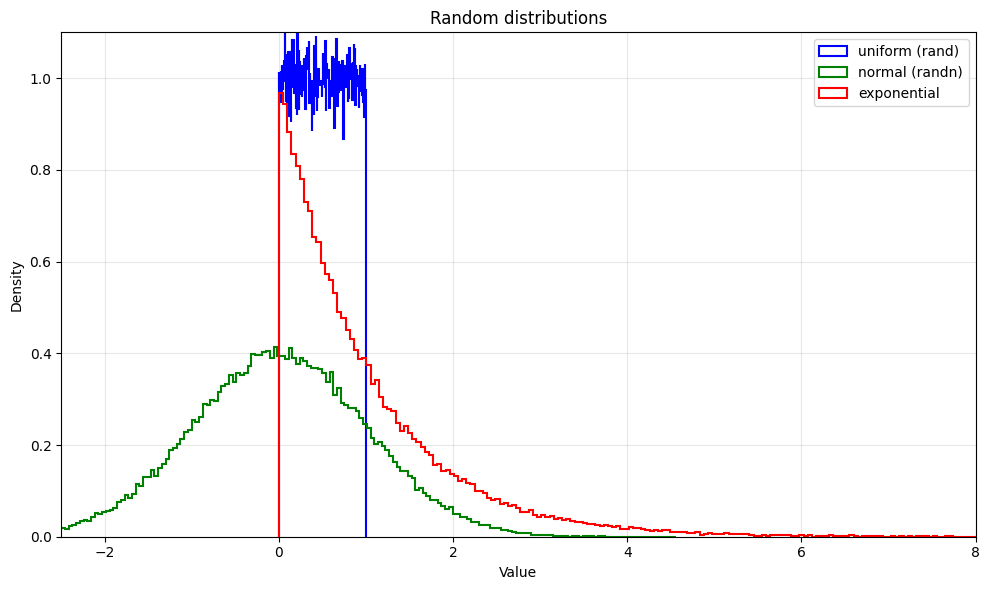

In [5]:
np.random.seed(42)

n_samples = 100000

# Uniform distribution [0, 1)
uniform_data = np.random.rand(n_samples)

# Normal (Gaussian) distribution, mean=0, std=1
normal_data = np.random.randn(n_samples)

# Exponential distribution (same as Task 1.1)
exponential_data = np.random.exponential(scale=1.0, size=n_samples)

plt.figure(figsize=(10, 6))

plt.hist(uniform_data, density=True, bins=200, histtype="step",
         color="blue", label="uniform (rand)", linewidth=1.5)
plt.hist(normal_data, density=True, bins=200, histtype="step",
         color="green", label="normal (randn)", linewidth=1.5)
plt.hist(exponential_data, density=True, bins=200, histtype="step",
         color="red", label="exponential", linewidth=1.5)

# Adjusted axis limits for a clearer view of all three distributions
plt.axis([-2.5, 8, 0, 1.1])
plt.legend(loc="upper right")
plt.title("Random distributions")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 3D plot of Z = X² + Y² with X, Y ∈ [-5, 5]

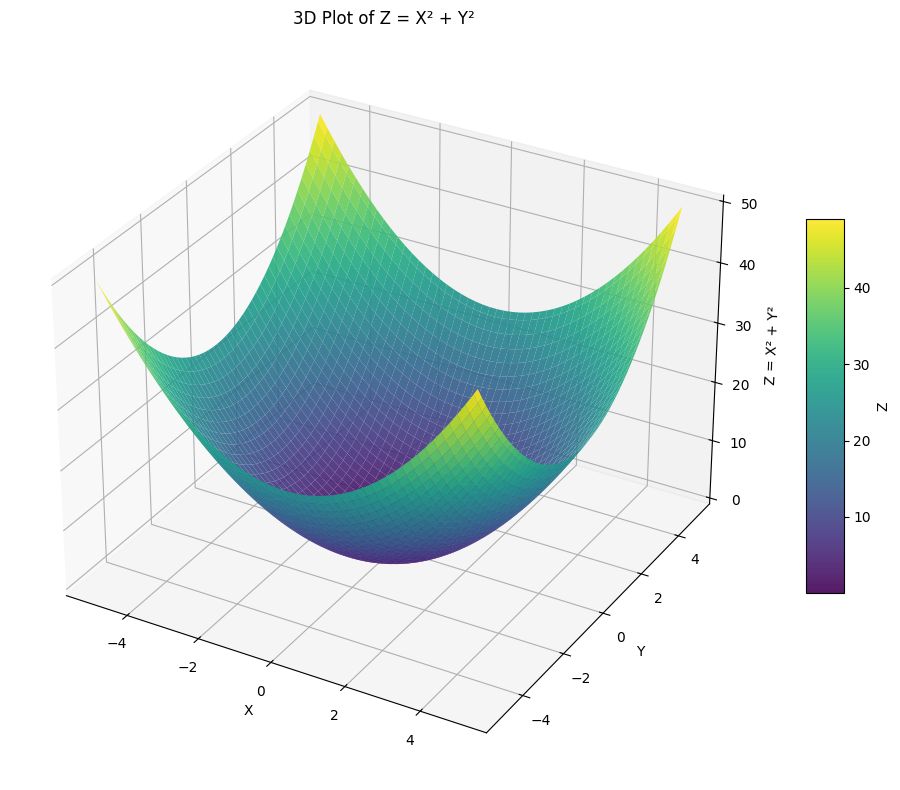

In [6]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.9)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label="Z")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z = X² + Y²")
ax.set_title("3D Plot of Z = X² + Y²")
plt.tight_layout()
plt.show()

## 4. Pearson & Spearman correlations for Pokémon stats (heatmaps)
Features: HP, Attack, Defense, Sp. Atk, Sp. Def, Speed

In [7]:
# Pokémon dataset (same source as Seaborn_Tutorial.ipynb)
# Local copy preferred; otherwise download (Wayback mirror of Elite Data Science file)
from pathlib import Path
import urllib.request

local_paths = [Path("Pokemon.csv"), Path("data/Pokemon.csv")]
csv_path = next((p for p in local_paths if p.exists()), None)

if csv_path is None:
    urls = [
        "https://elitedatascience.com/wp-content/uploads/2022/07/Pokemon.csv",
        "https://web.archive.org/web/20220701000000id_/"
        "https://elitedatascience.com/wp-content/uploads/2022/07/Pokemon.csv",
    ]
    for url in urls:
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as resp, open("Pokemon.csv", "wb") as out:
                out.write(resp.read())
            csv_path = Path("Pokemon.csv")
            print("Downloaded from:", url)
            break
        except Exception as e:
            print("Download failed:", e)
    if csv_path is None:
        raise FileNotFoundError("Could not load Pokemon.csv")

df = pd.read_csv(csv_path, index_col=0, encoding="latin")
print("Loaded:", csv_path, "shape:", df.shape)
df.head()

Downloaded from: https://elitedatascience.com/wp-content/uploads/2022/07/Pokemon.csv
Loaded: Pokemon.csv shape: (151, 12)


,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False


In [8]:
# Same feature set as Seaborn_Tutorial.ipynb heat-map section
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
stats_df = df[features]
# Equivalent to: df.drop(['Total', 'Stage', 'Legendary'], axis=1) then drop Type columns
stats_df.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
#,,,,,,
1,45,49,49,65,65,45
2,60,62,63,80,80,60
3,80,82,83,100,100,80
4,39,52,43,60,50,65
5,58,64,58,80,65,80


Pearson correlation coefficients:


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
HP,1.000000,0.306768,0.119782,0.236649,0.490978,-0.040939
Attack,0.306768,1.000000,0.491965,0.146312,0.369069,0.194701
Defense,0.119782,0.491965,1.000000,0.187569,0.139912,-0.053252
Sp. Atk,0.236649,0.146312,0.187569,1.000000,0.522907,0.411516
Sp. Def,0.490978,0.369069,0.139912,0.522907,1.000000,0.392656
Speed,-0.040939,0.194701,-0.053252,0.411516,0.392656,1.000000


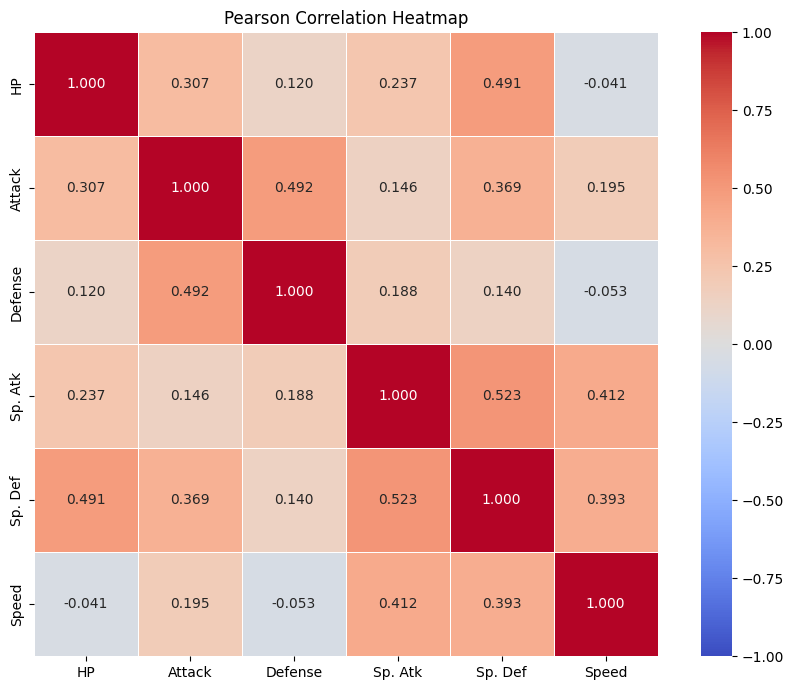

In [9]:
# Pearson standard correlation coefficient
pearson_corr = stats_df.corr(method="pearson")
print("Pearson correlation coefficients:")
display(pearson_corr)

plt.figure(figsize=(9, 7))
sns.heatmap(pearson_corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

Spearman rank correlation coefficients:


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
HP,1.000000,0.539356,0.390014,0.363993,0.566837,0.054014
Attack,0.539356,1.000000,0.541506,0.161862,0.386198,0.226590
Defense,0.390014,0.541506,1.000000,0.258751,0.250028,-0.033235
Sp. Atk,0.363993,0.161862,0.258751,1.000000,0.561665,0.384759
Sp. Def,0.566837,0.386198,0.250028,0.561665,1.000000,0.403588
Speed,0.054014,0.226590,-0.033235,0.384759,0.403588,1.000000


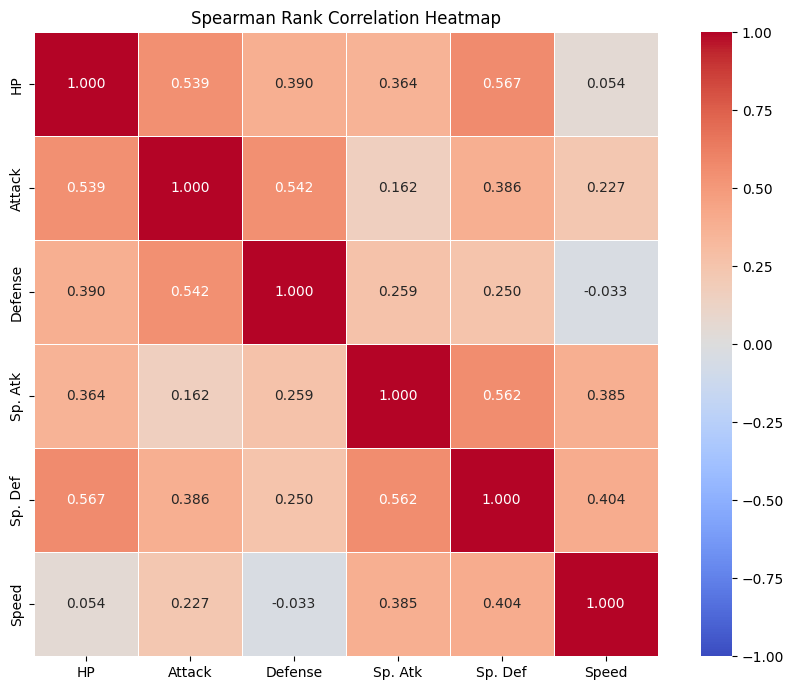

In [10]:
# Spearman rank correlation
spearman_corr = stats_df.corr(method="spearman")
print("Spearman rank correlation coefficients:")
display(spearman_corr)

plt.figure(figsize=(9, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Spearman Rank Correlation Heatmap")
plt.tight_layout()
plt.show()